# 0. CONFIG
This cell holds every parameter used downstream. Change the log path, drift case-index positions, and search ranges here before rerunning the notebook.


In [1]:
from pathlib import Path
from numpy.lib.stride_tricks import sliding_window_view

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from minisom import MiniSom
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.objects.log.importer.xes import importer as xes_importer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

# Setup, if the environment is missing packages:
# uv pip install pm4py minisom numpy pandas matplotlib seaborn scikit-learn

project_root = Path.cwd()
if not (project_root / "logs").exists() and (project_root.parent / "logs").exists():
    project_root = project_root.parent

log_path = project_root / "logs" / "sudden_drift_long.xes"
ground_truth_drifts = [5000]
w_search_range = list(range(2, 7))
d_search_range = list(range(2, 21))
M_search_range = [3, 4]
random_seed = 42

time_bin_freq = "1D"
som_iterations = 1000
som_sigma = 1.0
som_learning_rate = 0.5

np.random.seed(random_seed)


# 1. LOAD & SANITY CHECK
The XES log is loaded through PM4PY and normalized to `case_id`, `activity`, and `timestamp`. The summary checks the basic scale of the log before any modeling.


cases: 10,000
events: 296,578
activities: 30
time span: 2020-03-08 08:00:00+00:00 to 2049-05-04 02:15:30+00:00


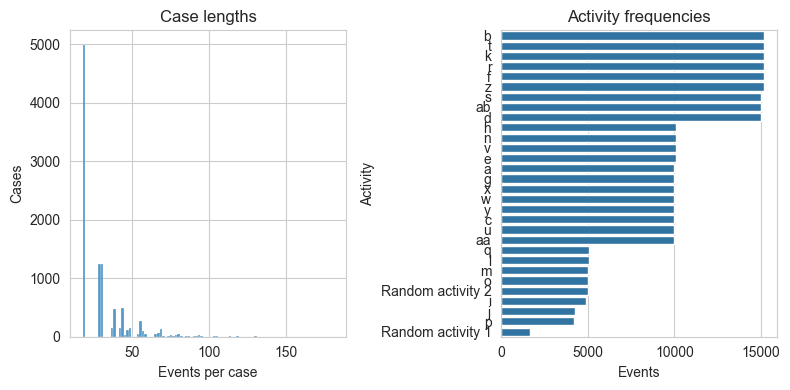

In [2]:
raw_log = xes_importer.apply(
    str(log_path),
    variant=xes_importer.Variants.ITERPARSE,
    parameters={"show_progress_bar": False},
)
df = log_converter.apply(raw_log, variant=log_converter.Variants.TO_DATA_FRAME)

column_aliases = {
    "case_id": ["case_id", "case:concept:name", "caseid", "case"],
    "activity": ["activity", "concept:name", "event", "task"],
    "timestamp": ["timestamp", "time:timestamp", "time", "datetime"],
}

rename_map = {}
for target, candidates in column_aliases.items():
    source = next((col for col in candidates if col in df.columns), None)
    if source is None:
        raise ValueError(f"Missing required column for {target}. Tried: {candidates}")
    rename_map[source] = target

df = df.rename(columns=rename_map).copy()
df["case_id"] = df["case_id"].astype(str)
df["activity"] = df["activity"].astype(str)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.dropna(subset=["timestamp"]).sort_values(["timestamp", "case_id"]).reset_index(drop=True)

case_start = df.groupby("case_id")["timestamp"].min().sort_values()
case_order = case_start.index.to_list()
case_index = pd.Series(np.arange(len(case_order)), index=case_order)
df["case_index"] = df["case_id"].map(case_index)

case_lengths = df.groupby("case_id").size().sort_values(ascending=False)
activity_counts = df["activity"].value_counts()

print(f"cases: {df['case_id'].nunique():,}")
print(f"events: {len(df):,}")
print(f"activities: {df['activity'].nunique():,}")
print(f"time span: {df['timestamp'].min()} to {df['timestamp'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sns.histplot(case_lengths, ax=axes[0])
axes[0].set_xlabel("Events per case")
axes[0].set_ylabel("Cases")
axes[0].set_title("Case lengths")

sns.barplot(x=activity_counts.values, y=activity_counts.index, ax=axes[1], orient="h")
axes[1].set_xlabel("Events")
axes[1].set_ylabel("Activity")
axes[1].set_title("Activity frequencies")

plt.tight_layout()
plt.show()


# 2. PER-EVENT FEATURE VECTORS
Each event becomes an intra-case vector: activity one-hot plus timing and normalized position features. The numeric features are standardized so PCA does not treat seconds as inherently more important than position.


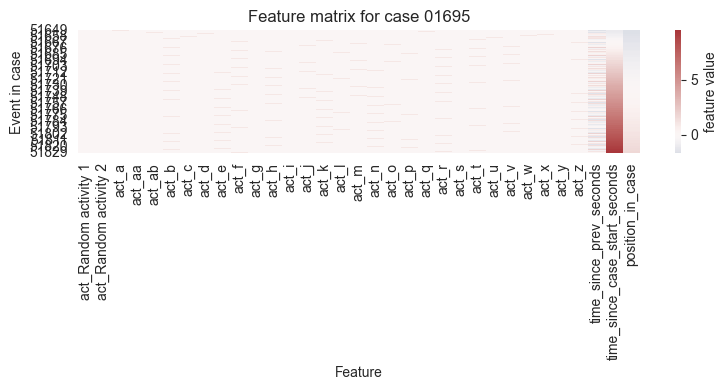

In [3]:
df_events = df.sort_values(["case_index", "timestamp", "activity"]).reset_index(drop=True).copy()
df_events["event_index_in_case"] = df_events.groupby("case_id").cumcount()
df_events["case_length"] = df_events.groupby("case_id")["activity"].transform("size")

time_diff = df_events.groupby("case_id")["timestamp"].diff().dt.total_seconds()
df_events["time_since_prev_seconds"] = time_diff.fillna(0.0)
df_events["time_since_case_start_seconds"] = (
    df_events["timestamp"] - df_events.groupby("case_id")["timestamp"].transform("min")
).dt.total_seconds()
df_events["position_in_case"] = np.where(
    df_events["case_length"] > 1,
    df_events["event_index_in_case"] / (df_events["case_length"] - 1),
    0.0,
)

numeric_columns = [
    "time_since_prev_seconds",
    "time_since_case_start_seconds",
    "position_in_case",
]
activity_dummies = pd.get_dummies(df_events["activity"], prefix="act", dtype=float)
activity_columns = activity_dummies.columns.to_list()
activity_names = [col.removeprefix("act_") for col in activity_columns]

scaler = StandardScaler()
numeric_features = pd.DataFrame(
    scaler.fit_transform(df_events[numeric_columns]),
    columns=numeric_columns,
    index=df_events.index,
)

event_features = pd.concat([activity_dummies, numeric_features], axis=1).astype("float32")
event_feature_names = event_features.columns.to_list()
event_feature_matrix = event_features.to_numpy(dtype="float32")
n_event_features = event_feature_matrix.shape[1]
n_activity_features = len(activity_columns)

example_case_id = case_lengths.index[0]
example_rows = df_events["case_id"].eq(example_case_id)
example_features = event_features.loc[example_rows]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(example_features, cmap="vlag", center=0, ax=ax, cbar_kws={"label": "feature value"})
ax.set_xlabel("Feature")
ax.set_ylabel("Event in case")
ax.set_title(f"Feature matrix for case {example_case_id}")
plt.tight_layout()
plt.show()


# 3. SLIDING WINDOWS + WINDOW SIZE SELECTION
For each candidate `w`, consecutive event vectors inside a case are concatenated into fixed-length windows. The selected `w*` is the elbow of the probe PCA reconstruction-error curve.


chosen w*: 5


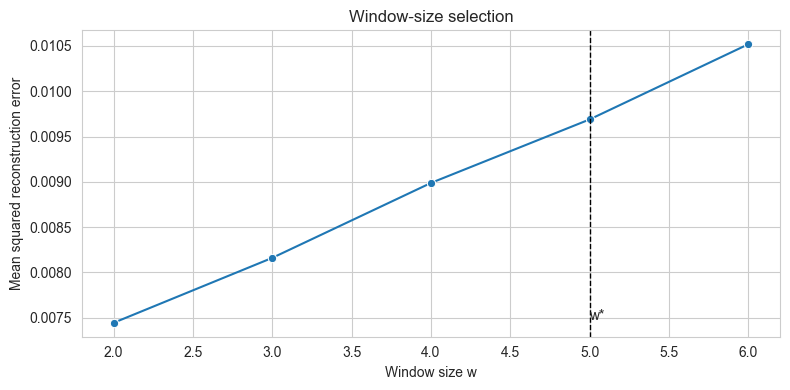

In [4]:
def build_sliding_windows(events, feature_matrix, w):
    window_blocks = []
    records = []

    for case_id, case_rows in events.groupby("case_id", sort=False).indices.items():
        rows = np.asarray(case_rows)
        if len(rows) < w:
            continue

        case_values = feature_matrix[rows]
        case_windows = sliding_window_view(case_values, window_shape=w, axis=0)
        case_windows = case_windows.transpose(0, 2, 1).reshape(len(rows) - w + 1, -1)
        window_blocks.append(case_windows)

        case_events = events.iloc[rows]
        for start in range(len(rows) - w + 1):
            window_events = case_events.iloc[start : start + w]
            records.append(
                {
                    "case_id": case_id,
                    "case_index": int(window_events["case_index"].iloc[0]),
                    "start_event_index": int(window_events["event_index_in_case"].iloc[0]),
                    "end_event_index": int(window_events["event_index_in_case"].iloc[-1]),
                    "start_time": window_events["timestamp"].iloc[0],
                    "end_time": window_events["timestamp"].iloc[-1],
                    "center_time": window_events["timestamp"].iloc[0]
                    + (window_events["timestamp"].iloc[-1] - window_events["timestamp"].iloc[0]) / 2,
                }
            )

    if not window_blocks:
        return np.empty((0, w * feature_matrix.shape[1]), dtype="float32"), pd.DataFrame(records)

    return np.vstack(window_blocks).astype("float32"), pd.DataFrame(records)


def fit_pca(X, n_components):
    solver = "randomized" if n_components < min(X.shape) else "full"
    kwargs = {"n_components": n_components, "svd_solver": solver}
    if solver == "randomized":
        kwargs["random_state"] = random_seed
    return PCA(**kwargs).fit(X)


def pca_reconstruction_error(X, fitted_pca, n_components=None):
    scores = fitted_pca.transform(X)
    if n_components is not None:
        scores = scores[:, :n_components]
    # Mean squared reconstruction error without materializing inverse_transform(X).
    centered_sq = float(np.einsum("ij,ij->", X, X, dtype=np.float64))
    centered_sq -= X.shape[0] * float(np.dot(fitted_pca.mean_, fitted_pca.mean_))
    captured_sq = float(np.einsum("ij,ij->", scores, scores, dtype=np.float64))
    return max(centered_sq - captured_sq, 0.0) / X.size


def choose_elbow(xs, ys):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    valid = np.isfinite(ys)
    xs = xs[valid]
    ys = ys[valid]
    if len(xs) <= 2:
        return int(xs[np.argmin(ys)])

    x_norm = (xs - xs.min()) / (xs.max() - xs.min())
    y_norm = (ys - ys.min()) / (ys.max() - ys.min()) if ys.max() > ys.min() else np.zeros_like(ys)
    line = np.column_stack([x_norm[[0, -1]], y_norm[[0, -1]]])
    points = np.column_stack([x_norm, y_norm])
    line_vector = line[1] - line[0]
    point_vectors = line[0] - points
    distances = np.abs(line_vector[0] * point_vectors[:, 1] - line_vector[1] * point_vectors[:, 0])
    distances = distances / np.linalg.norm(line_vector)
    return int(xs[np.argmax(distances)])

w_errors = []
for w in w_search_range:
    X_w, _ = build_sliding_windows(df_events, event_feature_matrix, w)
    if len(X_w) <= 1:
        w_errors.append(np.nan)
        continue

    probe_dim = min(max(d_search_range), X_w.shape[1], X_w.shape[0])
    probe_pca = fit_pca(X_w, probe_dim)
    w_errors.append(pca_reconstruction_error(X_w, probe_pca))

chosen_w = choose_elbow(w_search_range, w_errors)
print(f"chosen w*: {chosen_w}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(x=w_search_range, y=w_errors, marker="o", ax=ax)
ax.axvline(chosen_w, color="black", linestyle="--", linewidth=1)
ax.annotate("w*", xy=(chosen_w, np.nanmin(w_errors)), xytext=(chosen_w, np.nanmin(w_errors)), ha="left", va="bottom")
ax.set_xlabel("Window size w")
ax.set_ylabel("Mean squared reconstruction error")
ax.set_title("Window-size selection")
plt.tight_layout()
plt.show()


# 4. PCA COMPRESSION + DIMENSION SELECTION
With `w*` fixed, PCA compresses each intra-case window into a lower-dimensional vector. The chosen `d*` is read from the reconstruction-error elbow while the variance curve shows how much structure is retained.


chosen d*: 7


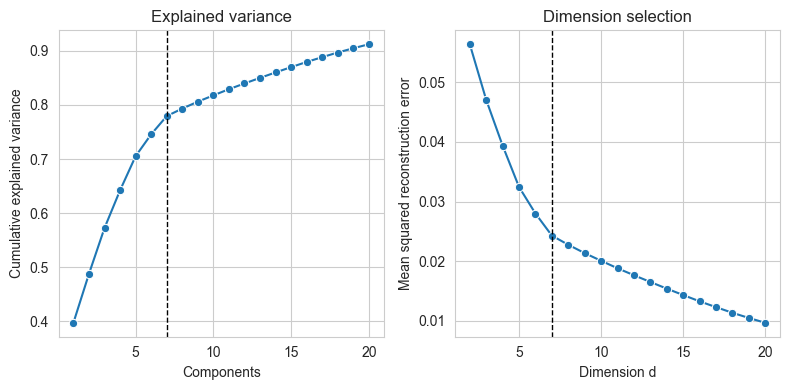

In [5]:
X_windows, window_df = build_sliding_windows(df_events, event_feature_matrix, chosen_w)
if len(X_windows) <= 1:
    raise ValueError("TODO: the selected window size produced too few windows; lower w_search_range.")

max_d = min(max(d_search_range), X_windows.shape[1], X_windows.shape[0])
valid_d = [d for d in d_search_range if d <= max_d]
pca_probe = fit_pca(X_windows, max_d)
pca_scores_full = pca_probe.transform(X_windows)

total_centered_sq = float(np.einsum("ij,ij->", X_windows, X_windows, dtype=np.float64))
total_centered_sq -= X_windows.shape[0] * float(np.dot(pca_probe.mean_, pca_probe.mean_))
component_sq = np.sum(np.square(pca_scores_full, dtype=np.float64), axis=0)
captured_sq = np.cumsum(component_sq)
d_errors = [max(total_centered_sq - captured_sq[d - 1], 0.0) / X_windows.size for d in valid_d]

chosen_d = choose_elbow(valid_d, d_errors)
pca_scores = pca_scores_full[:, :chosen_d]
print(f"chosen d*: {chosen_d}")

components = np.arange(1, max_d + 1)
cum_variance = np.cumsum(pca_probe.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
sns.lineplot(x=components, y=cum_variance, marker="o", ax=axes[0])
axes[0].axvline(chosen_d, color="black", linestyle="--", linewidth=1)
axes[0].set_xlabel("Components")
axes[0].set_ylabel("Cumulative explained variance")
axes[0].set_title("Explained variance")

sns.lineplot(x=valid_d, y=d_errors, marker="o", ax=axes[1])
axes[1].axvline(chosen_d, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel("Dimension d")
axes[1].set_ylabel("Mean squared reconstruction error")
axes[1].set_title("Dimension selection")

plt.tight_layout()
plt.show()


# 5. PCA SCATTER (intuition check)
The first two principal components give a quick geometric check of the compressed windows. Coloring by dominant activity helps reveal whether local activity content aligns with the PCA structure.


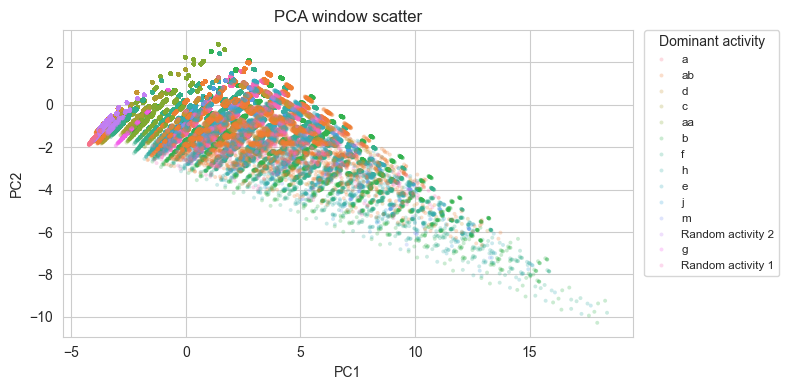

In [6]:
window_tensor = X_windows.reshape(len(X_windows), chosen_w, n_event_features)
window_activity_counts = window_tensor[:, :, :n_activity_features].sum(axis=1)
dominant_activity = np.asarray(activity_names)[window_activity_counts.argmax(axis=1)]
window_df["dominant_activity"] = dominant_activity

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(
    x=pca_scores_full[:, 0],
    y=pca_scores_full[:, 1],
    hue=dominant_activity,
    s=8,
    alpha=0.25,
    linewidth=0,
    ax=ax,
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA window scatter")
ax.legend(title="Dominant activity", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize="small")
plt.tight_layout()
plt.show()


# 6. SOM TRAINING + GRID SIZE SELECTION
Each candidate grid is trained on the `d*` PCA vectors. The grid score balances sequential neighbor preservation with cell utilization entropy.


chosen M: 3


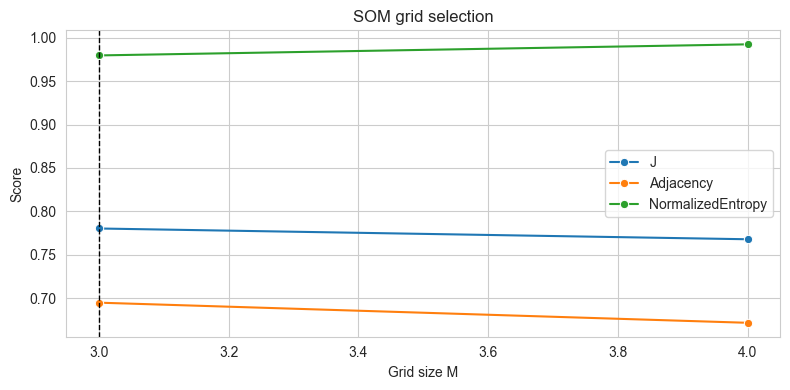

In [7]:
def train_som(M, data):
    som_model = MiniSom(
        M,
        M,
        data.shape[1],
        sigma=som_sigma,
        learning_rate=som_learning_rate,
        random_seed=random_seed,
    )
    som_model.random_weights_init(data)
    som_model.train_random(data, som_iterations, verbose=False)
    return som_model


def map_bmus(som_model, data):
    return np.asarray([som_model.winner(row) for row in data], dtype=int)


def adjacency_score(metadata, bmus):
    ordered = metadata.assign(bmu_x=bmus[:, 0], bmu_y=bmus[:, 1]).sort_values(
        ["case_index", "start_event_index"]
    )
    same_case = ordered["case_id"].eq(ordered["case_id"].shift())
    dx = (ordered["bmu_x"] - ordered["bmu_x"].shift()).abs()
    dy = (ordered["bmu_y"] - ordered["bmu_y"].shift()).abs()
    adjacent = same_case & (np.maximum(dx, dy) <= 1)
    return float(adjacent[same_case].mean()) if same_case.any() else 0.0


def normalized_entropy(bmus, M):
    flat_cells = bmus[:, 0] * M + bmus[:, 1]
    counts = np.bincount(flat_cells, minlength=M * M).astype(float)
    probabilities = counts[counts > 0] / counts.sum()
    entropy = -np.sum(probabilities * np.log(probabilities))
    return float(entropy / np.log(M * M)) if M * M > 1 else 0.0

som_search = []
for M in M_search_range:
    candidate_som = train_som(M, pca_scores)
    candidate_bmus = map_bmus(candidate_som, pca_scores)
    adjacency = adjacency_score(window_df, candidate_bmus)
    entropy = normalized_entropy(candidate_bmus, M)
    score = 0.7 * adjacency + 0.3 * entropy
    som_search.append({"M": M, "Adjacency": adjacency, "NormalizedEntropy": entropy, "J": score})

som_search_df = pd.DataFrame(som_search)
chosen_M = int(som_search_df.loc[som_search_df["J"].idxmax(), "M"])
print(f"chosen M: {chosen_M}")

som = train_som(chosen_M, pca_scores)
bmus = map_bmus(som, pca_scores)
window_df["som_x"] = bmus[:, 0]
window_df["som_y"] = bmus[:, 1]
window_df["cell"] = [f"({x},{y})" for x, y in bmus]

fig, ax = plt.subplots(figsize=(8, 4))
for metric in ["J", "Adjacency", "NormalizedEntropy"]:
    sns.lineplot(data=som_search_df, x="M", y=metric, marker="o", label=metric, ax=ax)
ax.axvline(chosen_M, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("Grid size M")
ax.set_ylabel("Score")
ax.set_title("SOM grid selection")
ax.legend()
plt.tight_layout()
plt.show()


# 7. SOM INSPECTION
These heatmaps inspect the fitted SOM itself: topology distances, cell load, and local quantization error. Together they show whether the selected grid is both used and locally coherent.


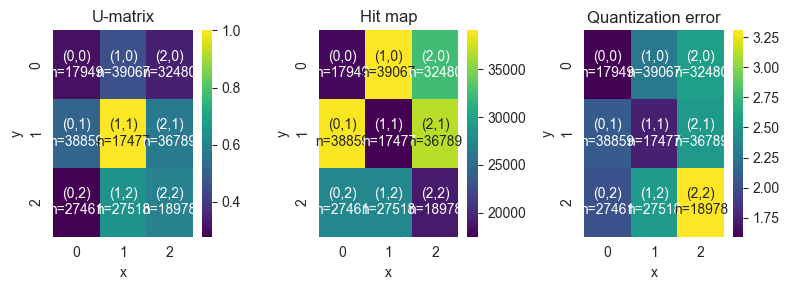

In [8]:
M = chosen_M
weights = som.get_weights()
hit_map = np.zeros((M, M), dtype=int)
quantization_sum = np.zeros((M, M), dtype=float)

for row, (x, y) in zip(pca_scores, bmus):
    hit_map[x, y] += 1
    quantization_sum[x, y] += np.linalg.norm(row - weights[x, y])

quantization_map = np.divide(
    quantization_sum,
    hit_map,
    out=np.full_like(quantization_sum, np.nan, dtype=float),
    where=hit_map > 0,
)
u_matrix = som.distance_map()
annotations = np.array([[f"({x},{y})\nn={hit_map[x, y]}" for x in range(M)] for y in range(M)])

fig, axes = plt.subplots(1, 3, figsize=(max(8, M * 2.4), max(3, M * 0.9)))
heatmaps = [
    (u_matrix.T, "U-matrix"),
    (hit_map.T, "Hit map"),
    (quantization_map.T, "Quantization error"),
]

for ax, (data, label) in zip(axes, heatmaps):
    sns.heatmap(data, annot=annotations, fmt="", cmap="viridis", ax=ax, cbar=True)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(label)

plt.tight_layout()
plt.show()


# 8. PER-CELL ACTIVITY PROFILES
Each cell aggregates the activity content of all windows mapped to it. This is the main interpretability view for assigning human state labels.


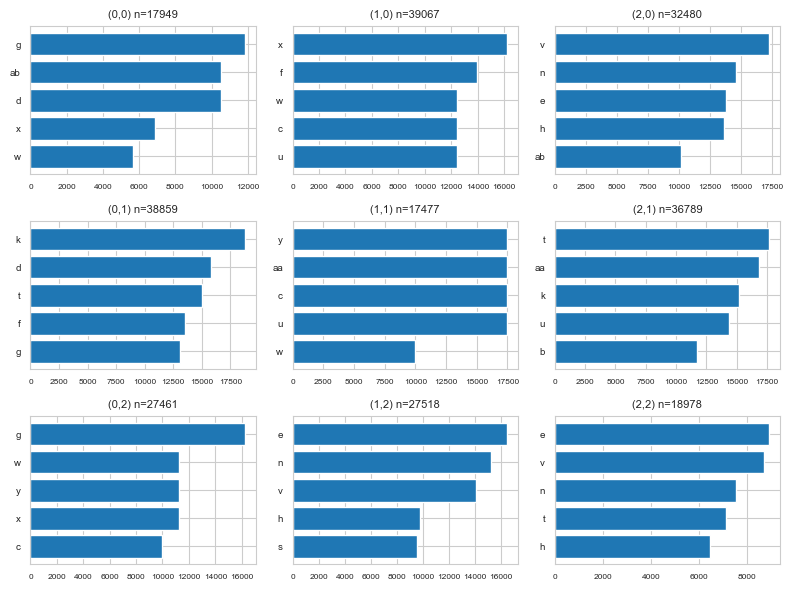

In [9]:
cell_activity_counts = np.zeros((M, M, n_activity_features), dtype=float)
for x in range(M):
    for y in range(M):
        cell_mask = (bmus[:, 0] == x) & (bmus[:, 1] == y)
        if cell_mask.any():
            cell_activity_counts[x, y] = window_activity_counts[cell_mask].sum(axis=0)

fig, axes = plt.subplots(M, M, figsize=(max(8, M * 2.4), max(6, M * 1.8)), squeeze=False)
for y in range(M):
    for x in range(M):
        ax = axes[y, x]
        counts = pd.Series(cell_activity_counts[x, y], index=activity_names).sort_values(ascending=False).head(5)
        if counts.sum() == 0:
            ax.text(0.5, 0.5, "empty", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.barh(counts.index[::-1], counts.values[::-1], color=sns.color_palette()[0])
        ax.set_title(f"({x},{y}) n={hit_map[x, y]}", fontsize=8)
        ax.tick_params(axis="y", labelsize=7)
        ax.tick_params(axis="x", labelsize=6)
        ax.set_xlabel("")
        ax.set_ylabel("")

plt.tight_layout()
plt.show()


# 9. STATE LABELS
Use the activity profiles above to assign a concise process-state name to each SOM cell. Keep the names stable enough to reuse in later drift interpretation.

| Cell | State label |
|---|---|
| (0,0) |  |
| (1,0) |  |
| (2,0) |  |
| (0,1) |  |
| (1,1) |  |
| (2,1) |  |
| (0,2) |  |
| (1,2) |  |
| (2,2) |  |


# 10. ONE EXAMPLE TRAJECTORY
A long case is projected onto the trained SOM to show how a single case moves through discovered states. Consecutive repeats are collapsed so the trajectory stays readable.


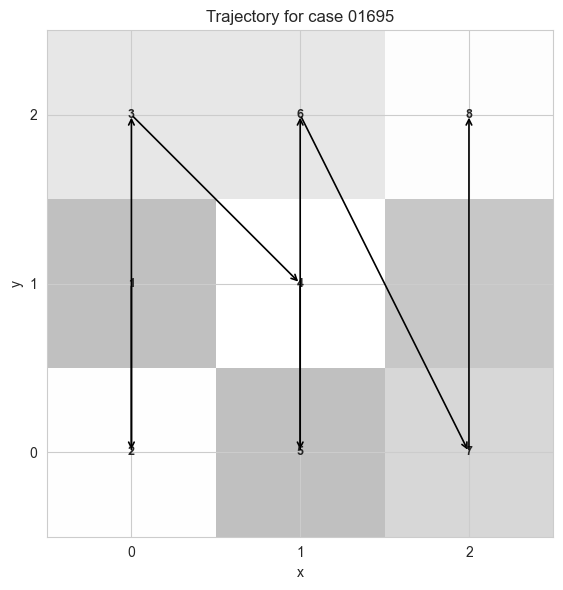

In [10]:
trajectory_case_id = case_lengths.index[0]
case_windows = window_df.loc[window_df["case_id"].eq(trajectory_case_id)].sort_values("start_event_index")
case_path = case_windows[["som_x", "som_y"]].drop_duplicates().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(max(6, M * 1.2), max(6, M * 1.2)))
ax.imshow(hit_map.T, origin="lower", cmap="Greys", alpha=0.25)
ax.set_xticks(range(M))
ax.set_yticks(range(M))
ax.set_xlim(-0.5, M - 0.5)
ax.set_ylim(-0.5, M - 0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Trajectory for case {trajectory_case_id}")

for step, row in case_path.iterrows():
    x, y = row["som_x"], row["som_y"]
    ax.text(x, y, str(step + 1), ha="center", va="center", fontsize=9, weight="bold")
    if step + 1 < len(case_path):
        next_row = case_path.iloc[step + 1]
        ax.annotate(
            "",
            xy=(next_row["som_x"], next_row["som_y"]),
            xytext=(x, y),
            arrowprops={"arrowstyle": "->", "color": "black", "linewidth": 1.2},
        )

plt.tight_layout()
plt.show()


# 11. CELL-OCCUPANCY OVER TIME (drift preview)
Window centers are binned in time, and each bin shows the fraction of active cases assigned to each SOM cell. Ground-truth drift positions are converted from case index to the corresponding case-start timestamp.


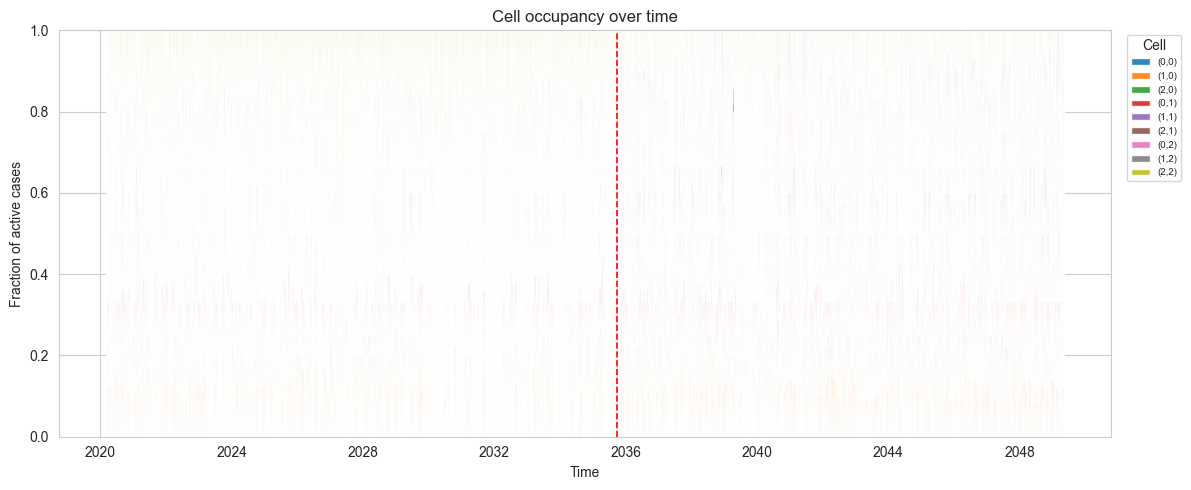

In [11]:
occupancy_df = window_df.copy()
occupancy_df["time_bin"] = occupancy_df["center_time"].dt.floor(time_bin_freq)
cell_order = [f"({x},{y})" for y in range(M) for x in range(M)]

cell_counts = (
    occupancy_df.groupby(["time_bin", "cell"])["case_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=cell_order, fill_value=0)
    .sort_index()
)
cell_fractions = cell_counts.div(cell_counts.sum(axis=1), axis=0).fillna(0)

case_start_by_index = case_start.reset_index().rename(columns={"timestamp": "case_start_time"})
drift_times = []
for drift_position in ground_truth_drifts:
    drift_index = min(max(int(drift_position), 0), len(case_start_by_index) - 1)
    drift_times.append(case_start_by_index.loc[drift_index, "case_start_time"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(cell_fractions.index, cell_fractions.T, labels=cell_fractions.columns, alpha=0.9)
for drift_time in drift_times:
    ax.axvline(drift_time, color="red", linestyle="--", linewidth=1.2)

ax.set_xlabel("Time")
ax.set_ylabel("Fraction of active cases")
ax.set_ylim(0, 1)
ax.set_title("Cell occupancy over time")
ax.legend(title="Cell", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize="x-small", ncol=1)
plt.tight_layout()
plt.show()
